# 01 · Exploratory Data Analysis

Dataset: **Diabetic Retinopathy 2015 Data Colored Resized** (Kaggle, EyePACS origin, 224×224, CC0).

This notebook:
1. Indexes every image and reads its stage label and patient ID
2. Plots the class distribution (imbalance)
3. Shows sample images for each stage
4. Checks image quality (brightness and blur)
5. Checks how often both eyes of a patient share the same stage
6. Creates the patient-level 70/15/15 split and plots the per-split distribution

All figures are saved to `outputs/figures/` for the report. Runs locally or in a Kaggle Notebook.

In [1]:
import os, sys
from pathlib import Path

# Locate the project root (this notebook lives in notebooks/).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# On Kaggle, find the attached dataset automatically (the folder that holds No_DR).
if Path("/kaggle/input").exists() and "DR_DATA_ROOT" not in os.environ:
    hits = [p.parent for p in Path("/kaggle/input").rglob("No_DR") if p.is_dir()]
    if hits:
        os.environ["DR_DATA_ROOT"] = str(hits[0].parent)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data.dataset_index import build_index
from src.data.split import patient_level_split, split_counts
from src.utils.config import load_config
from src.utils.seed import set_seed

cfg = load_config(ROOT / "configs" / "config.yaml")
set_seed(cfg["seed"])
P, D = cfg["paths"], cfg["data"]
CLASS_NAMES = D["class_names"]
FIG = P["figures_dir"]; FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
print("Data root:", P["data_root"])

Data root: /kaggle/input/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized/colored_images


## 1. Build the image index

In [2]:
df = build_index(P["data_root"], D["folder_to_label"], D["image_extensions"], D.get("labels_csv"))
df["stage"] = df["label"].map(dict(enumerate(CLASS_NAMES)))
print(f"{len(df):,} images from {df['patient_id'].nunique():,} patients")
df.head()

35,126 images from 17,563 patients


,image_id,patient_id,eye,label,path,stage
0,10_left,10,left,0,colored_images/No_DR/10_left.png,No DR
1,10_right,10,right,0,colored_images/No_DR/10_right.png,No DR
2,100_left,100,left,0,colored_images/No_DR/100_left.png,No DR
3,100_right,100,right,0,colored_images/No_DR/100_right.png,No DR
4,1000_left,1000,left,0,colored_images/No_DR/1000_left.png,No DR


## 2. Class distribution

,Stage,Count,Percent
0,No DR,25810,73.5
1,Mild,2443,7.0
2,Moderate,5292,15.1
3,Severe,873,2.5
4,Proliferative DR,708,2.0


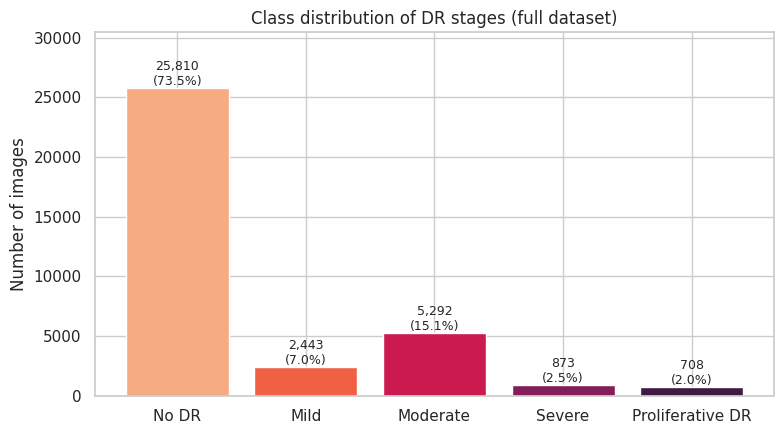

Imbalance ratio (largest / smallest class): 36.5 : 1


In [3]:
counts = df["label"].value_counts().sort_index()
dist = pd.DataFrame({"Stage": CLASS_NAMES, "Count": counts.values,
                     "Percent": (100 * counts / counts.sum()).round(1).values})
display(dist)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(CLASS_NAMES, counts.values, color=sns.color_palette("rocket_r", 5))
for b, pct in zip(bars, dist["Percent"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height()):,}\n({pct}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Class distribution of DR stages (full dataset)")
ax.set_ylabel("Number of images")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.savefig(FIG / "class_distribution.png", dpi=200); plt.show()

print(f"Imbalance ratio (largest / smallest class): {counts.max() / counts.min():.1f} : 1")

## 3. Sample images for each stage

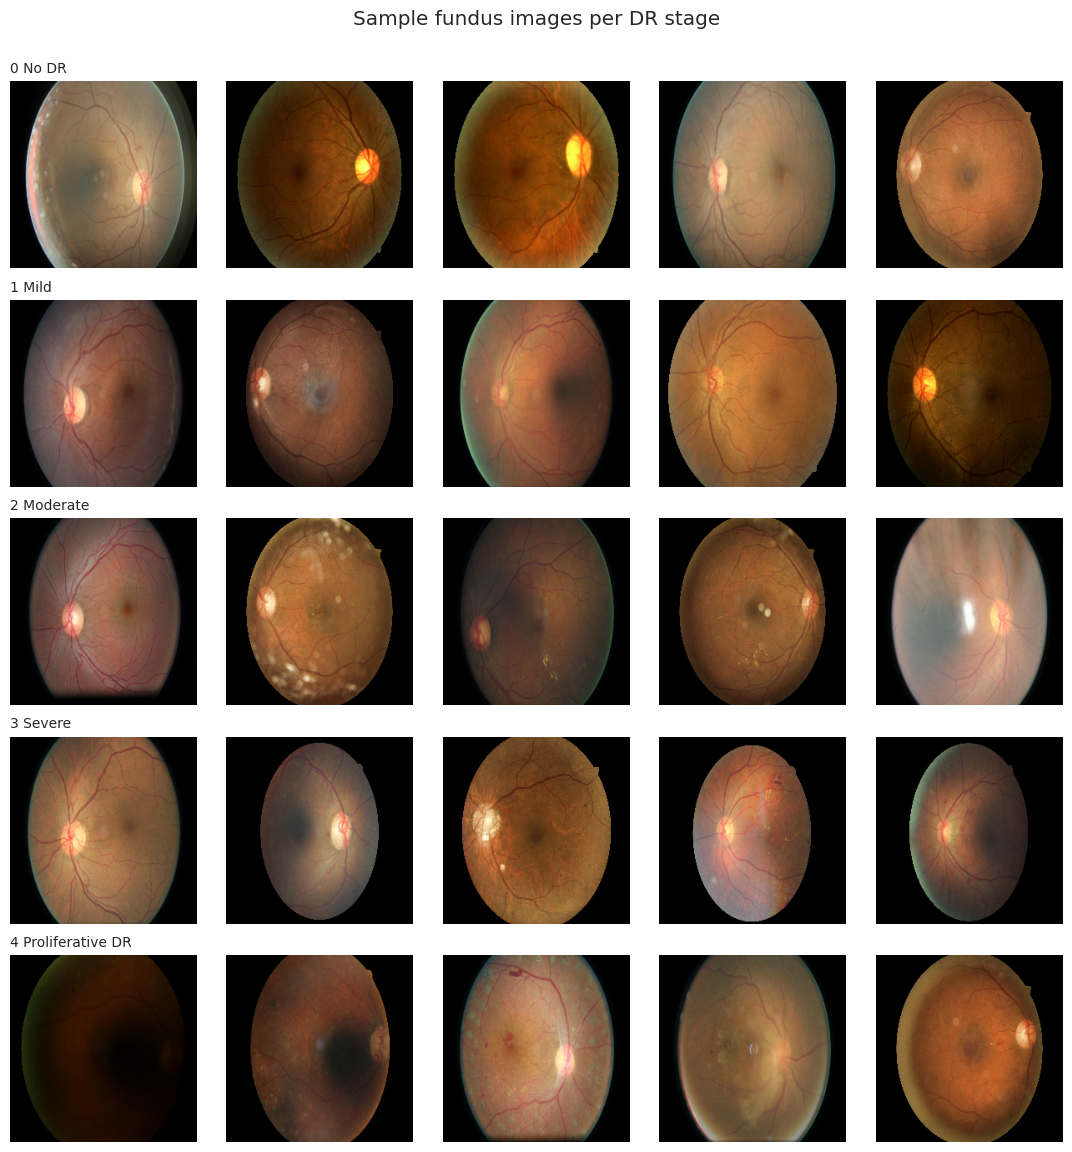

In [4]:
def load_rgb(rel_path):
    img = cv2.imread(str(P["data_root"] / rel_path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

N = 5
fig, axes = plt.subplots(5, N, figsize=(N * 2.2, 5 * 2.3))
for label in range(5):
    sample = df[df["label"] == label].sample(min(N, (df["label"] == label).sum()), random_state=cfg["seed"])
    for j in range(N):
        ax = axes[label, j]; ax.axis("off")
        if j < len(sample):
            ax.imshow(load_rgb(sample.iloc[j]["path"]))
    axes[label, 0].set_title(f"{label} {CLASS_NAMES[label]}", loc="left", fontsize=10)
plt.suptitle("Sample fundus images per DR stage", y=1.0)
plt.tight_layout(); plt.savefig(FIG / "sample_grid.png", dpi=200); plt.show()

## 4. Image quality

Two simple measures on a random sample:
- **Brightness**: mean grey level inside the retina (dark or overexposed images)
- **Sharpness**: variance of the Laplacian (low values mean blur)

,brightness,sharpness
count,3000.0,3000.0
mean,100.3,353.2
std,34.1,281.8
min,14.9,5.5
25%,74.9,173.7
50%,99.6,263.2
75%,123.4,435.8
max,246.9,2167.5


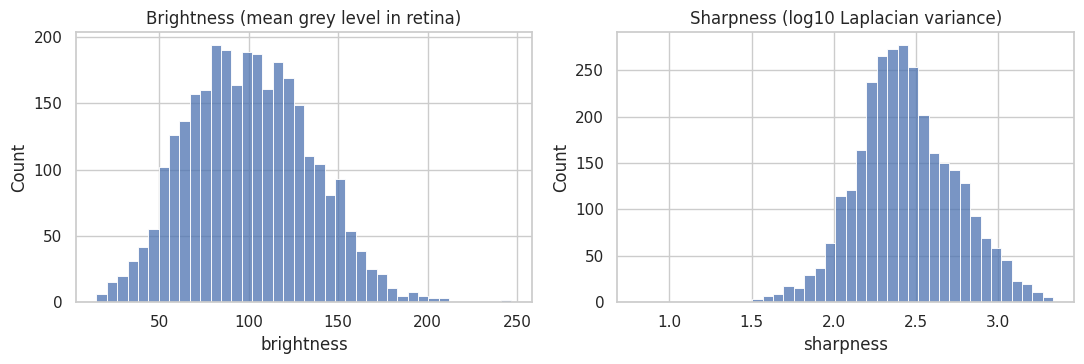

In [5]:
def quality(rel_path):
    grey = cv2.imread(str(P["data_root"] / rel_path), cv2.IMREAD_GRAYSCALE)
    mask = grey > cfg["preprocessing"]["border_threshold"]   # ignore the black border
    brightness = grey[mask].mean() if mask.any() else 0.0
    sharpness = cv2.Laplacian(grey, cv2.CV_64F).var()
    return brightness, sharpness

q = df.sample(min(3000, len(df)), random_state=cfg["seed"]).copy()
q[["brightness", "sharpness"]] = [quality(p) for p in q["path"]]
display(q[["brightness", "sharpness"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(q["brightness"], bins=40, ax=axes[0]); axes[0].set_title("Brightness (mean grey level in retina)")
sns.histplot(np.log10(q["sharpness"] + 1), bins=40, ax=axes[1]); axes[1].set_title("Sharpness (log10 Laplacian variance)")
plt.tight_layout(); plt.savefig(FIG / "image_quality_hist.png", dpi=200); plt.show()

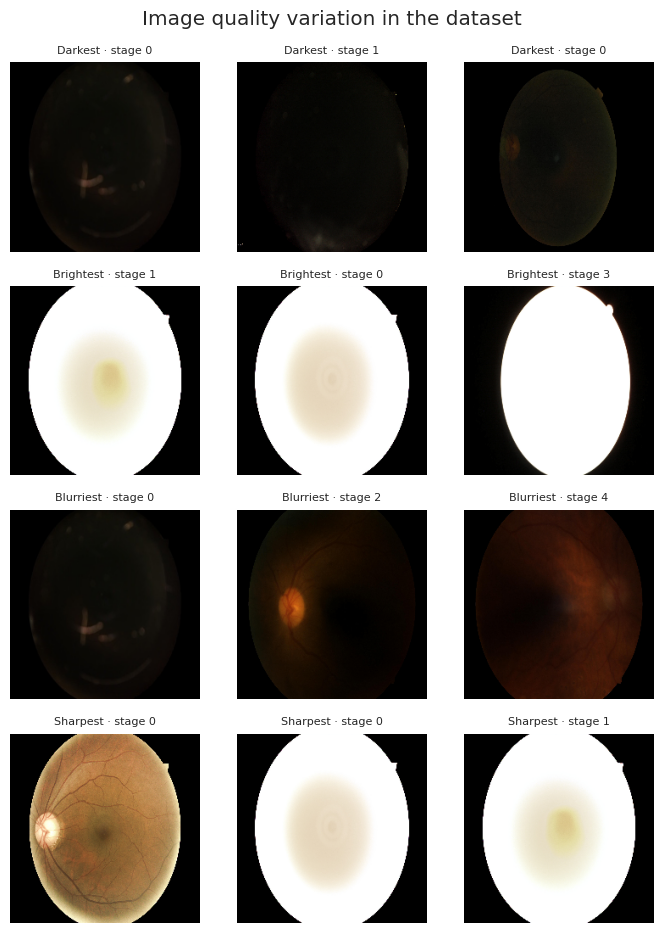

In [6]:
# Show the extremes: darkest, brightest, blurriest, sharpest
picks = {
    "Darkest": q.nsmallest(3, "brightness"),
    "Brightest": q.nlargest(3, "brightness"),
    "Blurriest": q.nsmallest(3, "sharpness"),
    "Sharpest": q.nlargest(3, "sharpness"),
}
fig, axes = plt.subplots(4, 3, figsize=(7, 9.5))
for i, (name, rows) in enumerate(picks.items()):
    for j in range(3):
        r = rows.iloc[j]; ax = axes[i, j]
        ax.imshow(load_rgb(r["path"])); ax.axis("off")
        ax.set_title(f"{name} · stage {r['label']}", fontsize=8)
plt.suptitle("Image quality variation in the dataset")
plt.tight_layout(); plt.savefig(FIG / "image_quality_examples.png", dpi=200); plt.show()

## 5. Left vs right eye

Both eyes of a patient are strongly correlated. This is the reason the split must be done by patient: otherwise one eye in training would "leak" information about the other eye in the test set.

Patients with both eyes: 17,563
Both eyes have the same stage: 87.2%


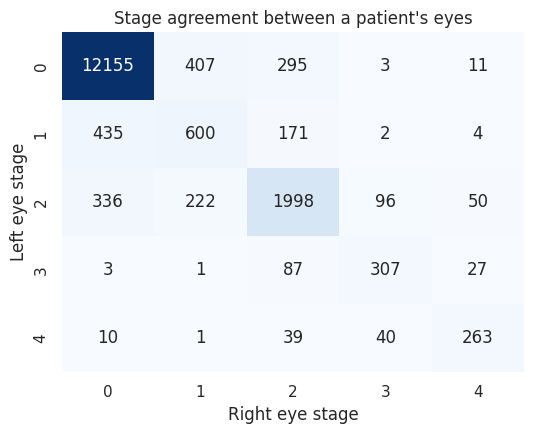

In [7]:
pairs = df.pivot_table(index="patient_id", columns="eye", values="label")
pairs = pairs.dropna(subset=[c for c in ("left", "right") if c in pairs])
same = (pairs["left"] == pairs["right"]).mean() * 100
print(f"Patients with both eyes: {len(pairs):,}")
print(f"Both eyes have the same stage: {same:.1f}%")

cm = pd.crosstab(pairs["left"].astype(int), pairs["right"].astype(int))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_xlabel("Right eye stage"); ax.set_ylabel("Left eye stage")
ax.set_title("Stage agreement between a patient's eyes")
plt.tight_layout(); plt.savefig(FIG / "eye_agreement.png", dpi=200); plt.show()

## 6. Patient-level stratified split (70 / 15 / 15)

In [8]:
S = cfg["split"]
splits = patient_level_split(df, S["train"], S["val"], S["test"], cfg["seed"])

P["splits_dir"].mkdir(parents=True, exist_ok=True)
for name, part in splits.items():
    part.drop(columns="stage").to_csv(P["splits_dir"] / f"{name}.csv", index=False)

# Leakage check: no patient may be in two splits.
ids = {k: set(v["patient_id"]) for k, v in splits.items()}
assert not (ids["train"] & ids["val"] or ids["train"] & ids["test"] or ids["val"] & ids["test"])
print("No patient appears in more than one split.")

table = split_counts(splits, CLASS_NAMES)
P["metrics_dir"].mkdir(parents=True, exist_ok=True)
table.to_csv(P["metrics_dir"] / "split_counts.csv")
display(table)

No patient appears in more than one split.


,train,val,test
0 No DR,18070,3865,3875
1 Mild,1708,367,368
2 Moderate,3704,798,790
3 Severe,611,133,129
4 Proliferative DR,495,105,108
Total,24588,5268,5270


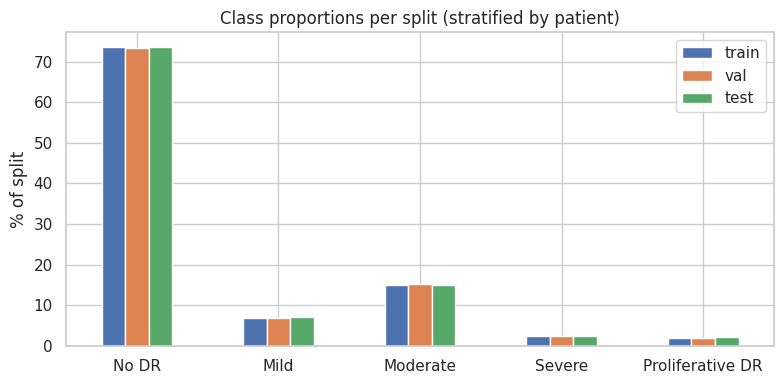

In [9]:
pct = pd.DataFrame({k: v["label"].value_counts(normalize=True).sort_index() * 100
                    for k, v in splits.items()})
pct.index = CLASS_NAMES
ax = pct.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("% of split"); ax.set_title("Class proportions per split (stratified by patient)")
plt.tight_layout(); plt.savefig(FIG / "split_distribution.png", dpi=200); plt.show()

## 7. Summary

- Figures saved to `outputs/figures/`: `class_distribution.png`, `sample_grid.png`, `image_quality_hist.png`, `image_quality_examples.png`, `eye_agreement.png`, `split_distribution.png`
- Split CSVs saved to `data/splits/`, counts to `outputs/metrics/split_counts.csv`
- Key points for the next stages: heavy class imbalance (handled with class weights / weighted sampling), wide variation in brightness and sharpness (handled by CLAHE and Ben Graham preprocessing), and strong correlation between eyes (handled by the patient-level split).